In [310]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")  # sube de /notebooks a la raíz del proyecto

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [311]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [3]:
import os
import sys

PROJECT_ROOT = r"C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)
print("scripts existe?:", os.path.exists(os.path.join(PROJECT_ROOT, "scripts")))

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos
scripts existe?: True


In [4]:
from scripts.database import test_connection
print("Importación correcta")
print(test_connection())

Importación correcta
True


In [2]:
import os
import sys
from dotenv import load_dotenv

PROJECT_ROOT = os.path.abspath("..")
ENV_PATH = os.path.join(PROJECT_ROOT, ".env")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ENV_PATH:", ENV_PATH)
print("¿Existe .env?:", os.path.exists(ENV_PATH))

load_dotenv(ENV_PATH, override=True)

print("DB_HOST:", os.getenv("DB_HOST"))
print("DB_PORT:", os.getenv("DB_PORT"))
print("DB_USER:", os.getenv("DB_USER"))
print("DB_NAME:", os.getenv("DB_NAME"))

pwd = os.getenv("DB_PASSWORD")
print("¿Password cargada?:", pwd is not None)
print("Longitud password:", len(pwd) if pwd else 0)

PROJECT_ROOT: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos
ENV_PATH: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos\.env
¿Existe .env?: True
DB_HOST: localhost
DB_PORT: 5432
DB_USER: postgres
DB_NAME: catalogo_videojuegos
¿Password cargada?: True
Longitud password: 11


In [13]:
import pandas as pd

df_csv = pd.read_csv("../data/igdb.csv")
print(df_csv.shape)
df_csv.head()

(99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [14]:
print(df_csv.columns.tolist())

['query', 'id', 'nombre', 'fecha_lanzamiento', 'rating', 'rating_count', 'generos', 'plataformas', 'cover_url', 'fecha_extraccion']


In [15]:
from scripts.database import engine

df_csv.to_sql("juegos_csv", engine, if_exists="replace", index=False)
print("Tabla juegos_csv cargada en PostgreSQL")

Tabla juegos_csv cargada en PostgreSQL


In [16]:
query = "SELECT * FROM juegos_csv LIMIT 10"
df_real = pd.read_sql(query, engine)
print(df_real.shape)
df_real.head()

(10, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [17]:
query = "SELECT * FROM juegos_csv"
df_real = pd.read_sql(query, engine)

print("Dimensiones:", df_real.shape)
df_real.head()

Dimensiones: (99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [18]:
df_model = df_real.copy()

# Convertir fecha_lanzamiento desde epoch/Unix seconds
df_model["fecha_lanzamiento"] = pd.to_datetime(
    df_model["fecha_lanzamiento"],
    unit="s",
    errors="coerce"
)

# Año de lanzamiento
df_model["release_year"] = df_model["fecha_lanzamiento"].dt.year

# Cantidad de géneros
df_model["genre_count"] = (
    df_model["generos"]
    .fillna("")
    .apply(lambda x: len([g for g in str(x).split(",") if g.strip()]))
)

# Cantidad de plataformas
df_model["platform_count"] = (
    df_model["plataformas"]
    .fillna("")
    .apply(lambda x: len([p for p in str(x).split(",") if p.strip()]))
)

# Longitud del nombre del juego
df_model["title_length"] = df_model["nombre"].fillna("").str.len()

print("Dimensiones antes de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones antes de limpiar: (99, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [19]:
df_model = df_model.dropna(subset=["rating", "rating_count", "release_year"]).copy()

print("Dimensiones después de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones después de limpiar: (42, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [20]:
features_real = [
    "release_year",
    "rating_count",
    "genre_count",
    "platform_count",
    "title_length"
]

X_real_reg = df_model[features_real]
y_real_reg = df_model["rating"]

print("X_real_reg:", X_real_reg.shape)
print("y_real_reg:", y_real_reg.shape)
print(X_real_reg.head())

X_real_reg: (42, 5)
y_real_reg: (42,)
   release_year  rating_count  genre_count  platform_count  title_length
0        1986.0         705.0            1               6            19
1        1987.0         289.0            3               5            31
2        2001.0         164.0            3               2            35
3        2001.0         189.0            3               2            38
4        1991.0        1632.0            2               6            39


In [21]:
umbral = 65
df_model["rating_bin"] = (df_model["rating"] >= umbral).astype(int)

print("Conteo por clase:")
print(df_model["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df_model["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Conteo por clase:
rating_bin
0     8
1    34
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.1905
1    0.8095
Name: proportion, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [23]:
X_train_real_reg, X_test_real_reg, y_train_real_reg, y_test_real_reg = train_test_split(
    X_real_reg, y_real_reg, test_size=0.2, random_state=42
)

print("Entrenamiento X:", X_train_real_reg.shape)
print("Prueba X:", X_test_real_reg.shape)
print("Entrenamiento y:", y_train_real_reg.shape)
print("Prueba y:", y_test_real_reg.shape)

Entrenamiento X: (33, 5)
Prueba X: (9, 5)
Entrenamiento y: (33,)
Prueba y: (9,)


In [24]:
tree_real_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_real_reg.fit(X_train_real_reg, y_train_real_reg)

y_pred_real_reg = tree_real_reg.predict(X_test_real_reg)

r2_real_reg = r2_score(y_test_real_reg, y_pred_real_reg)
mse_real_reg = mean_squared_error(y_test_real_reg, y_pred_real_reg)
rmse_real_reg = np.sqrt(mse_real_reg)
mae_real_reg = mean_absolute_error(y_test_real_reg, y_pred_real_reg)

print("ÁRBOL DE REGRESIÓN - DATOS REALES")
print("R²:", round(r2_real_reg, 4))
print("MSE:", round(mse_real_reg, 4))
print("RMSE:", round(rmse_real_reg, 4))
print("MAE:", round(mae_real_reg, 4))

ÁRBOL DE REGRESIÓN - DATOS REALES
R²: 0.4506
MSE: 99.4297
RMSE: 9.9714
MAE: 8.7585


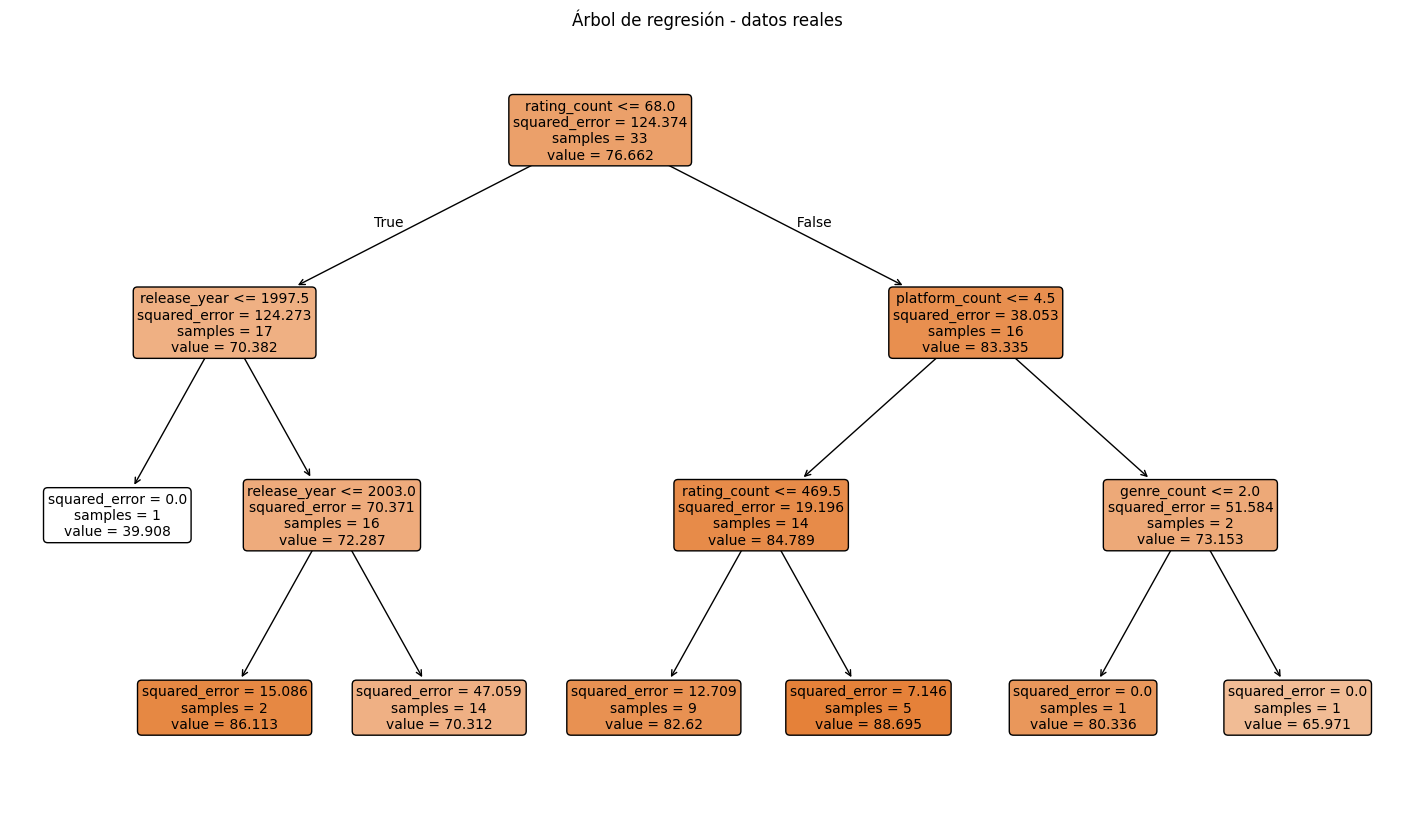

In [25]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_real_reg,
    feature_names=X_real_reg.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de regresión - datos reales")
plt.show()

In [26]:
reglas_real_reg = export_text(tree_real_reg, feature_names=list(X_real_reg.columns))
print("REGLAS - ÁRBOL DE REGRESIÓN REAL")
print(reglas_real_reg)

REGLAS - ÁRBOL DE REGRESIÓN REAL
|--- rating_count <= 68.00
|   |--- release_year <= 1997.50
|   |   |--- value: [39.91]
|   |--- release_year >  1997.50
|   |   |--- release_year <= 2003.00
|   |   |   |--- value: [86.11]
|   |   |--- release_year >  2003.00
|   |   |   |--- value: [70.31]
|--- rating_count >  68.00
|   |--- platform_count <= 4.50
|   |   |--- rating_count <= 469.50
|   |   |   |--- value: [82.62]
|   |   |--- rating_count >  469.50
|   |   |   |--- value: [88.69]
|   |--- platform_count >  4.50
|   |   |--- genre_count <= 2.00
|   |   |   |--- value: [80.34]
|   |   |--- genre_count >  2.00
|   |   |   |--- value: [65.97]



In [27]:
X_real_bin = df_model[features_real]
y_real_bin = df_model["rating_bin"]

print("X_real_bin:", X_real_bin.shape)
print("y_real_bin:", y_real_bin.shape)
print(y_real_bin.value_counts().sort_index())

X_real_bin: (42, 5)
y_real_bin: (42,)
rating_bin
0     8
1    34
Name: count, dtype: int64


In [28]:
X_train_real_bin, X_test_real_bin, y_train_real_bin, y_test_real_bin = train_test_split(
    X_real_bin, y_real_bin, test_size=0.2, random_state=42, stratify=y_real_bin
)

print("Entrenamiento X:", X_train_real_bin.shape)
print("Prueba X:", X_test_real_bin.shape)
print("Distribución entrenamiento:")
print(y_train_real_bin.value_counts().sort_index())
print("Distribución prueba:")
print(y_test_real_bin.value_counts().sort_index())

Entrenamiento X: (33, 5)
Prueba X: (9, 5)
Distribución entrenamiento:
rating_bin
0     6
1    27
Name: count, dtype: int64
Distribución prueba:
rating_bin
0    2
1    7
Name: count, dtype: int64


In [298]:
import sys
!{sys.executable} -m pip install python-dotenv sqlalchemy psycopg2-binary

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------- ------------------------- 1.0/2.8 MB 10.4 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.8 MB 6.6 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.8 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [python-dotenv]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, probplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
n = 1000

# Variables con distintas distribuciones
release_year = np.random.randint(2015, 2026, n)                    # discreta
metascore = np.clip(np.random.normal(76, 9, n), 45, 98)           # normal
price_usd = np.clip(np.random.normal(45, 12, n), 10, 80)          # normal
hours_gameplay = np.clip(np.random.gamma(4, 10, n), 5, 120)       # gamma
marketing_score = np.clip(np.random.lognormal(2.0, 0.6, n), 2, 120)  # lognormal
social_hype = np.random.beta(2, 5, n) * 100                       # beta
discount_pct = np.random.uniform(0, 60, n)                        # uniforme
bugs_reported = np.random.poisson(6, n)                           # poisson

# rating_count depende de marketing y hype
rating_count = (
    marketing_score * 95
    + social_hype * 25
    + np.random.normal(0, 180, n)
)
rating_count = np.clip(rating_count, 50, None).round()

# rating depende de varias variables
rating = (
    8
    + 0.65 * metascore
    + 0.05 * hours_gameplay
    + 0.035 * social_hype
    + 0.0032 * rating_count
    - 0.95 * bugs_reported
    - 0.08 * price_usd
    + 0.06 * discount_pct
    + np.random.normal(0, 2.2, n)
)

rating = np.clip(rating, 50, 99)

df = pd.DataFrame({
    "release_year": release_year,
    "metascore": metascore.round(2),
    "price_usd": price_usd.round(2),
    "hours_gameplay": hours_gameplay.round(2),
    "marketing_score": marketing_score.round(2),
    "social_hype": social_hype.round(2),
    "discount_pct": discount_pct.round(2),
    "bugs_reported": bugs_reported,
    "rating_count": rating_count.astype(int),
    "rating": rating.round(2)
})

df.head()

,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [243]:
df.to_csv("../data/videojuegos_sinteticos.csv", index=False)
print("CSV guardado en ../data/videojuegos_sinteticos.csv")

CSV guardado en ../data/videojuegos_sinteticos.csv


In [244]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nResumen estadístico:")
display(df.describe())

Dimensiones: (1000, 10)

Tipos de datos:
release_year         int32
metascore          float64
price_usd          float64
hours_gameplay     float64
marketing_score    float64
social_hype        float64
discount_pct       float64
bugs_reported        int32
rating_count         int64
rating             float64
dtype: object

Resumen estadístico:


,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019.84000,76.686010,45.144000,40.256780,8.72309,28.885840,30.003330,6.088000,1553.341000,58.873950
std,3.15854,8.997272,11.717681,20.009478,5.46138,15.923036,17.645377,2.611719,685.138903,6.530026
min,2015.00000,49.930000,10.000000,5.000000,2.00000,0.650000,0.010000,0.000000,200.000000,50.000000
25%,2017.00000,70.757500,37.245000,25.880000,4.97750,16.490000,14.860000,4.000000,1082.750000,53.630000
50%,2020.00000,76.560000,45.080000,37.445000,7.37500,26.720000,29.320000,6.000000,1427.000000,58.260000
75%,2023.00000,82.477500,53.052500,51.262500,10.80500,39.490000,45.842500,8.000000,1937.250000,63.315000
max,2025.00000,98.000000,80.000000,120.000000,45.10000,81.970000,59.960000,15.000000,4824.000000,81.630000


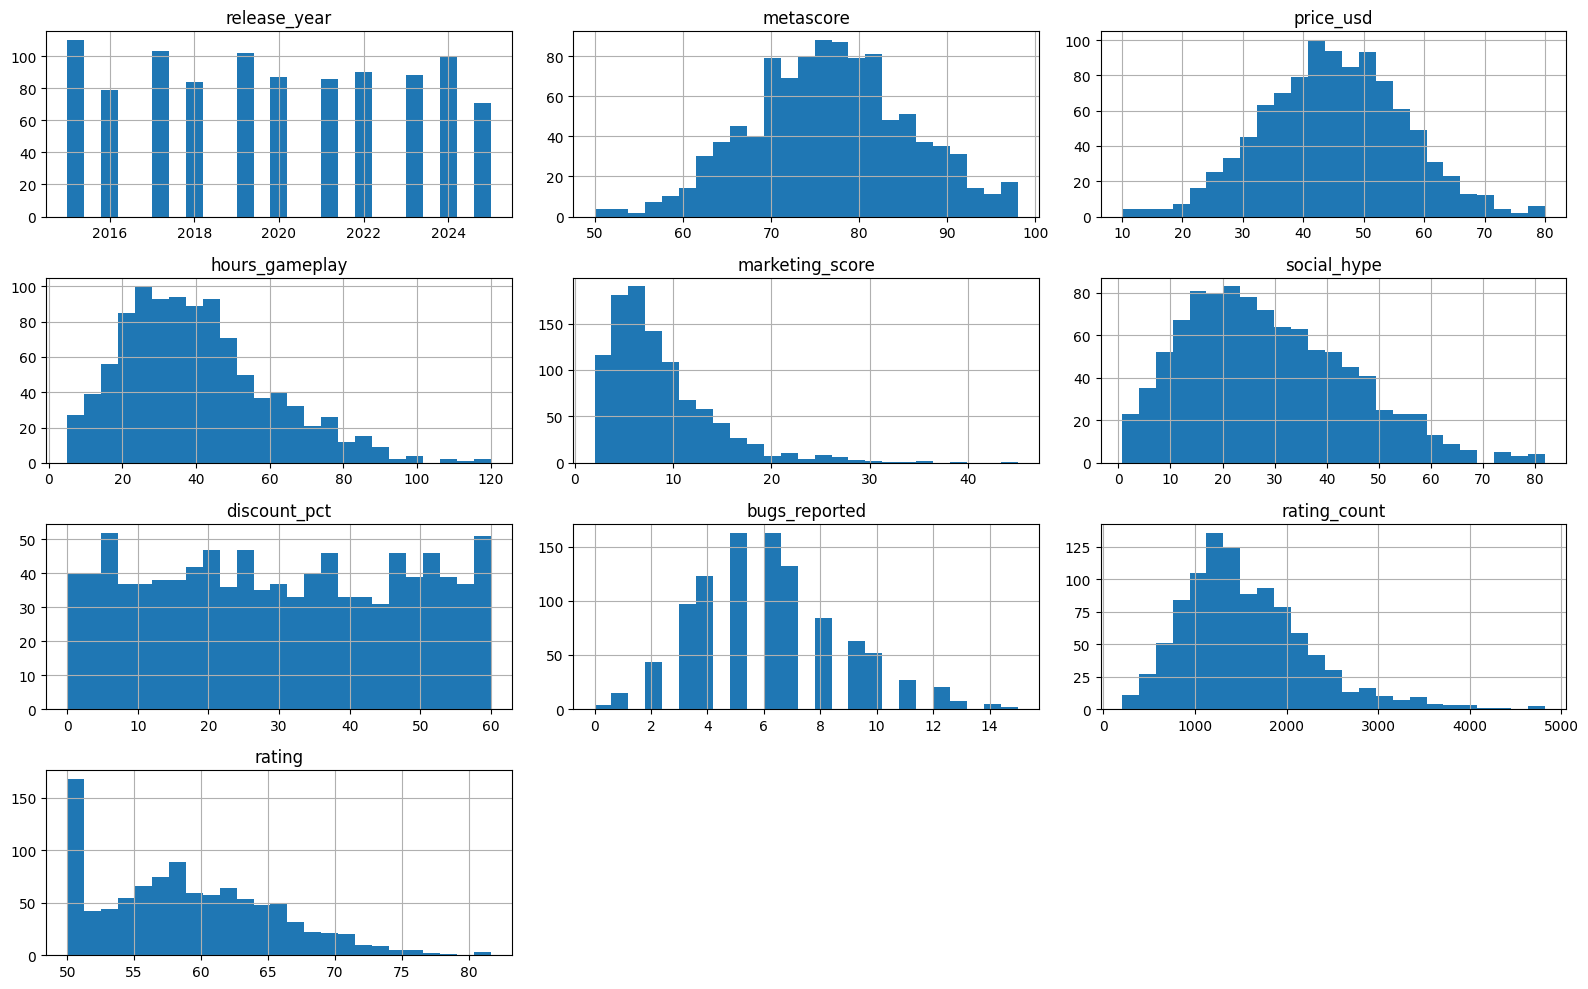

In [245]:
df.hist(figsize=(16, 10), bins=25)
plt.tight_layout()
plt.show()

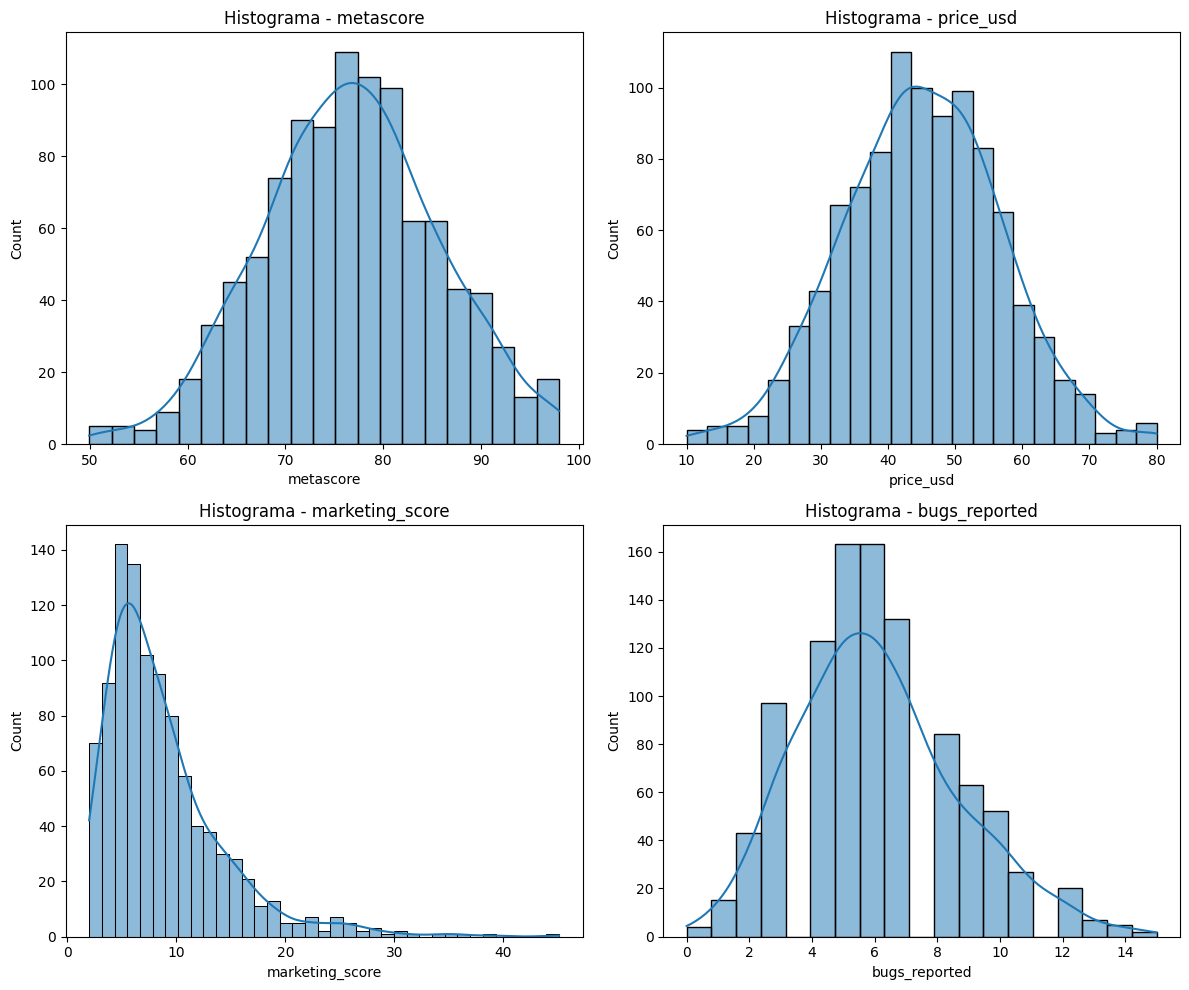

In [246]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df["metascore"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histograma - metascore")

sns.histplot(df["price_usd"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Histograma - price_usd")

sns.histplot(df["marketing_score"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histograma - marketing_score")

sns.histplot(df["bugs_reported"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Histograma - bugs_reported")

plt.tight_layout()
plt.show()

In [247]:
variables_normalidad = ["metascore", "price_usd", "marketing_score", "rating"]

for col in variables_normalidad:
    stat, p = shapiro(df[col].sample(500, random_state=42))  # muestra de 500 para evitar problemas
    print(f"{col}: estadístico={stat:.4f}, p-valor={p:.4f}")
    if p > 0.05:
        print(" -> Se puede considerar aproximadamente normal\n")
    else:
        print(" -> No sigue una normalidad estricta\n")

metascore: estadístico=0.9965, p-valor=0.3394
 -> Se puede considerar aproximadamente normal

price_usd: estadístico=0.9977, p-valor=0.7164
 -> Se puede considerar aproximadamente normal

marketing_score: estadístico=0.8315, p-valor=0.0000
 -> No sigue una normalidad estricta

rating: estadístico=0.9573, p-valor=0.0000
 -> No sigue una normalidad estricta



In [260]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

print("Entrenamiento X:", X_train_t.shape)
print("Prueba X:", X_test_t.shape)
print("Entrenamiento y:", y_train_t.shape)
print("Prueba y:", y_test_t.shape)

Entrenamiento X: (800, 7)
Prueba X: (200, 7)
Entrenamiento y: (800,)
Prueba y: (200,)


In [261]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

In [262]:
tree_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train_t, y_train_t)

print("Árbol de regresión entrenado correctamente")

Árbol de regresión entrenado correctamente


In [263]:
y_pred_t = tree_model.predict(X_test_t)

r2_t = r2_score(y_test_t, y_pred_t)
mse_t = mean_squared_error(y_test_t, y_pred_t)
rmse_t = np.sqrt(mse_t)
mae_t = mean_absolute_error(y_test_t, y_pred_t)

print("ÁRBOL DE REGRESIÓN")
print("R²:", round(r2_t, 4))
print("MSE:", round(mse_t, 4))
print("RMSE:", round(rmse_t, 4))
print("MAE:", round(mae_t, 4))

ÁRBOL DE REGRESIÓN
R²: 0.652
MSE: 14.8296
RMSE: 3.8509
MAE: 3.0311


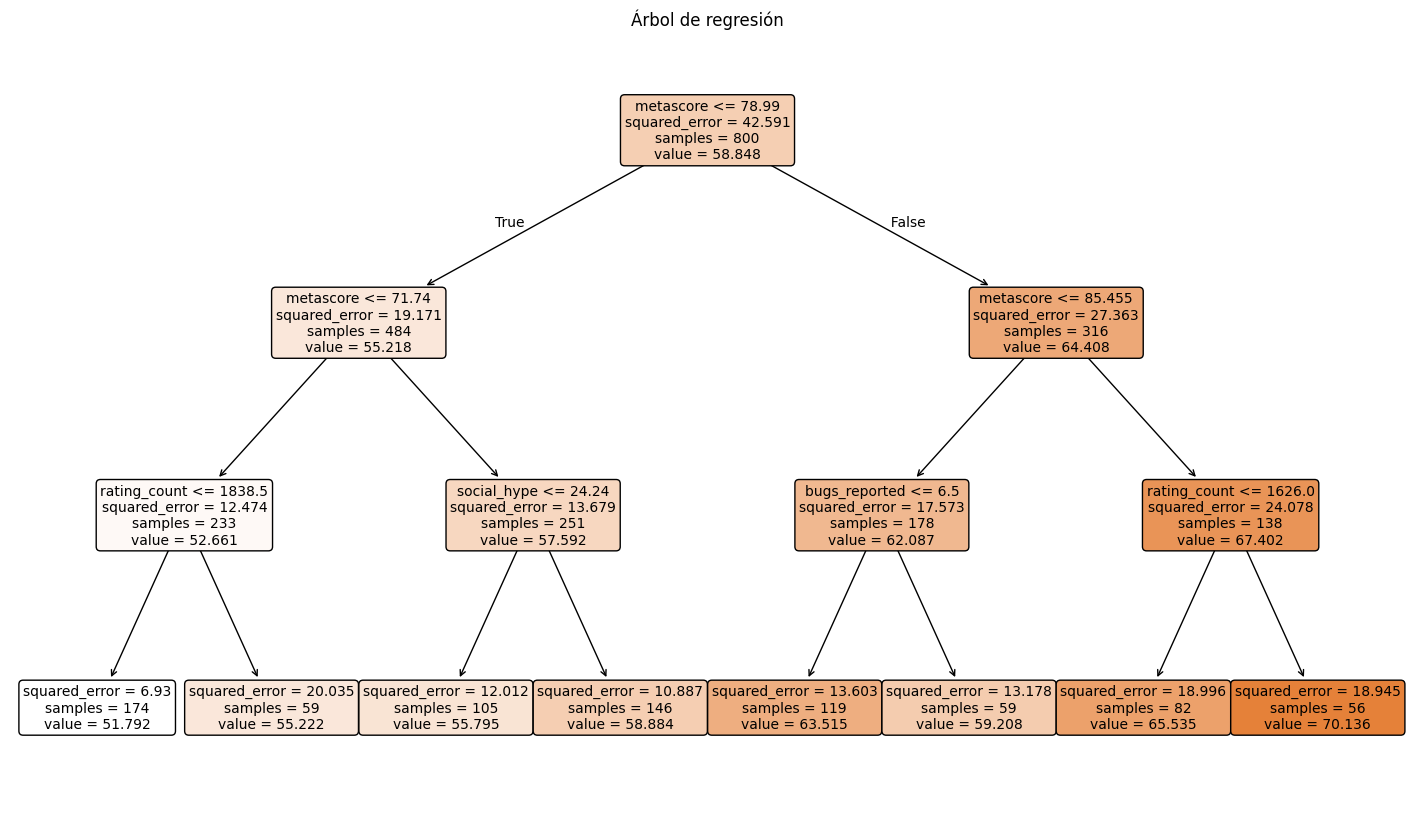

In [264]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_model,
    feature_names=X_tree.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de regresión")
plt.show()

In [265]:
reglas = export_text(tree_model, feature_names=list(X_tree.columns))
print("REGLAS DE DECISIÓN - ÁRBOL DE REGRESIÓN")
print(reglas)

REGLAS DE DECISIÓN - ÁRBOL DE REGRESIÓN
|--- metascore <= 78.99
|   |--- metascore <= 71.74
|   |   |--- rating_count <= 1838.50
|   |   |   |--- value: [51.79]
|   |   |--- rating_count >  1838.50
|   |   |   |--- value: [55.22]
|   |--- metascore >  71.74
|   |   |--- social_hype <= 24.24
|   |   |   |--- value: [55.80]
|   |   |--- social_hype >  24.24
|   |   |   |--- value: [58.88]
|--- metascore >  78.99
|   |--- metascore <= 85.45
|   |   |--- bugs_reported <= 6.50
|   |   |   |--- value: [63.51]
|   |   |--- bugs_reported >  6.50
|   |   |   |--- value: [59.21]
|   |--- metascore >  85.45
|   |   |--- rating_count <= 1626.00
|   |   |   |--- value: [65.54]
|   |   |--- rating_count >  1626.00
|   |   |   |--- value: [70.14]

